# 02 Classify

Turns the annual MNDWI composites into water / land masks in `data/interim/masks/`, one per year from 2014 to 2026, and writes the threshold table to `outputs/tables/02_thresholds.csv`. All logic lives in `src/reclaim/classify.py`; parameters come from `config.yaml`.

- Sentinel-2 (2015-2026): one Otsu threshold per year, computed from pixels inside the Singapore boundary with `n_obs >= min_valid_obs`. A fixed threshold is not usable: the water share swings by more than the real reclamation signal from year to year.
- Landsat 8 (2014 only): the threshold that gives the same water fraction as the Sentinel-2 masks in the overlap years 2015 and 2016.
- Each mask has two bands: `water` (1 water, 0 land, 255 nodata) and `low_obs` (1 where `n_obs < min_valid_obs`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from reclaim import config, classify
cfg = config.load()

## 1. Masks and threshold table

`mask` is True for the rows that produced a mask. The Landsat rows for 2015 and 2016 are calibration only. `land_km2` is land inside the boundary; `sla_km2` is the official SLA land area.

In [2]:
table, curve = classify.run(cfg)
table

2015 s2: threshold 0.240 -> mask_2015.tif


2016 s2: threshold 0.270 -> mask_2016.tif


2017 s2: threshold 0.271 -> mask_2017.tif


2018 s2: threshold 0.261 -> mask_2018.tif


2019 s2: threshold 0.272 -> mask_2019.tif


...

2024 s2: threshold 0.278 -> mask_2024.tif


2025 s2: threshold 0.264 -> mask_2025.tif


2026 s2: threshold 0.237 -> mask_2026.tif


2014 landsat: threshold 0.257 -> mask_2014.tif
wrote outputs/tables/02_thresholds.csv


,year,sensor,mask,threshold,land_km2,water_pct,low_obs_pct,agreement_with_s2,sla_km2
0,2014,landsat,True,0.2575,668.54,52.11,5.44,NaN,718.9
1,2015,landsat,False,0.2575,671.77,51.87,10.62,97.24,719.1
2,2015,s2,True,0.2402,681.48,51.09,2.82,NaN,719.1
3,2016,landsat,False,0.2575,693.21,50.31,17.05,98.73,719.7
4,2016,s2,True,0.2697,697.38,50.04,0.01,NaN,719.7
5,2017,s2,True,0.2708,709.22,49.19,0.00,NaN,721.5
6,2018,s2,True,0.2610,714.96,48.78,0.00,NaN,724.2
7,2019,s2,True,0.2718,713.78,48.87,0.00,NaN,725.7
8,2020,s2,True,0.2562,717.27,48.62,0.00,NaN,728.3
9,2021,s2,True,0.2783,722.41,48.25,0.00,NaN,733.1


## 2. Thresholds by year

Sentinel-2 thresholds should stay close to each other. A year that jumps away would point to a bad composite.

Sentinel-2 thresholds: 0.237 to 0.280 (range 0.042)


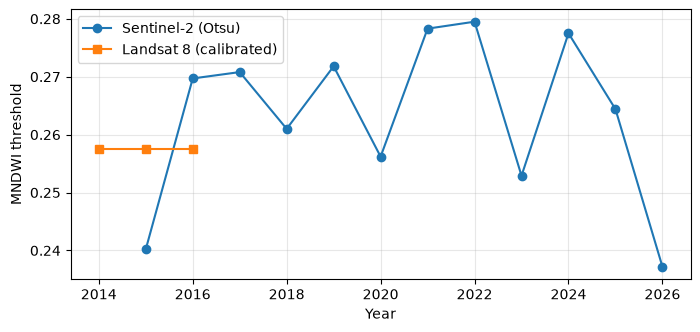

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for key, marker in [('s2', 'o'), ('landsat', 's')]:
    t = table[table.sensor == key]
    ax.plot(t.year, t.threshold, marker=marker, label={'s2': 'Sentinel-2 (Otsu)', 'landsat': 'Landsat 8 (calibrated)'}[key])
ax.set_xlabel('Year'); ax.set_ylabel('MNDWI threshold'); ax.legend(); ax.grid(alpha=0.3)
s2 = table[table.sensor == 's2'].threshold
print(f'Sentinel-2 thresholds: {s2.min():.3f} to {s2.max():.3f} (range {s2.max() - s2.min():.3f})')

## 3. Land area against SLA

The mask series rises in the same direction as SLA. The level sits below SLA because inland reservoirs count as water in the masks but as land in SLA's figure. From 2017 on the gap stays between about 5 and 12 km².

2014-2016 do not fit that pattern. The gap to SLA is 22-50 km² there, and the masks gain about 41 km² from 2014 to 2017 while SLA gains 2.6 km². 2014 is Landsat (30 m, fewer clear observations) and 2015 is the weakest Sentinel-2 year (the satellite started mid-year, 26 scenes). Year-to-year noise of this size is why stage 3 requires two water years and two land years, not a single change. 2015 and 2026 are only used to confirm neighbouring years and never appear in the results.

,year,sensor,land_km2,sla_km2,diff_km2,land_change,sla_change
0,2014,landsat,668.54,718.9,50.36,NaN,NaN
2,2015,s2,681.48,719.1,37.62,12.94,0.2
4,2016,s2,697.38,719.7,22.32,15.90,0.6
5,2017,s2,709.22,721.5,12.28,11.84,1.8
6,2018,s2,714.96,724.2,9.24,5.74,2.7
7,2019,s2,713.78,725.7,11.92,-1.18,1.5
8,2020,s2,717.27,728.3,11.03,3.49,2.6
9,2021,s2,722.41,733.1,10.69,5.14,4.8
10,2022,s2,727.18,734.3,7.12,4.77,1.2
11,2023,s2,726.50,735.2,8.70,-0.68,0.9


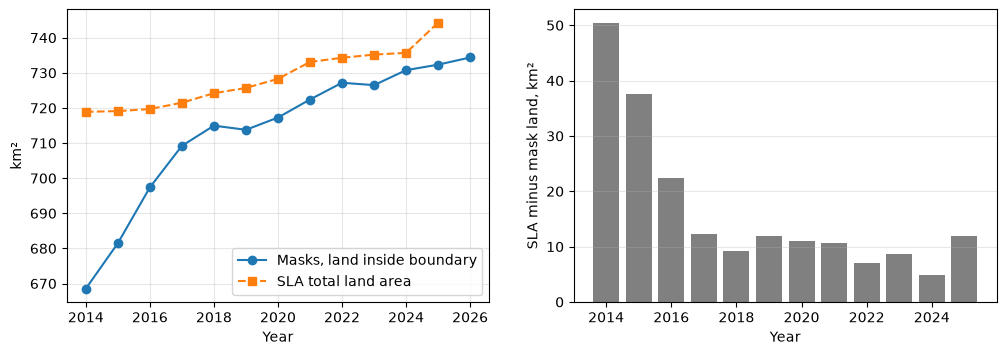

In [4]:
m = table[table['mask']]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(m.year, m.land_km2, 'o-', label='Masks, land inside boundary')
ax[0].plot(m.year, m.sla_km2, 's--', label='SLA total land area')
ax[0].set_ylabel('km²'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].bar(m.year, m.sla_km2 - m.land_km2, color='grey')
ax[1].set_ylabel('SLA minus mask land, km²'); ax[1].grid(alpha=0.3, axis='y')
for a in ax: a.set_xlabel('Year')
m[['year', 'sensor', 'land_km2', 'sla_km2']].assign(diff_km2=m.sla_km2 - m.land_km2,
                                                    land_change=m.land_km2.diff(), sla_change=m.sla_km2.diff())

## 4. Landsat calibration

The Landsat threshold is chosen so that Landsat and Sentinel-2 give the same water fraction on the shared valid pixels of 2015 and 2016. The curve shows pixel agreement for every candidate threshold.

The agreement maximum sits at a higher threshold, but there the disagreement is one-sided. Landsat calls land where Sentinel-2 sees water (2015: 21.5 vs 4.4 km²), mostly mixed 30 m pixels at the coast. A land-biased 2014 would remove valid 2016 detections in stage 3. Area matching splits the disagreement evenly for less than one point of agreement. Per-year agreement at the chosen threshold is in the `agreement_with_s2` column.

,year,threshold,agreement_with_s2,land_km2,low_obs_pct
0,2014,0.2575,NaN,668.54,5.44
1,2015,0.2575,97.24,671.77,10.62
3,2016,0.2575,98.73,693.21,17.05


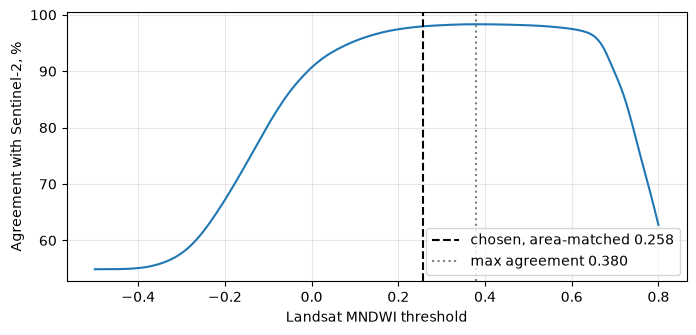

In [5]:
t_l8 = table[table.sensor == 'landsat'].threshold.iloc[0]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(curve.threshold, curve.agreement * 100)
ax.axvline(t_l8, color='k', ls='--', label=f'chosen, area-matched {t_l8:.3f}')
best = curve.loc[curve.agreement.idxmax()]
ax.axvline(best.threshold, color='grey', ls=':', label=f'max agreement {best.threshold:.3f}')
ax.set_xlabel('Landsat MNDWI threshold'); ax.set_ylabel('Agreement with Sentinel-2, %'); ax.legend(); ax.grid(alpha=0.3)
table[table.sensor == 'landsat'][['year', 'threshold', 'agreement_with_s2', 'land_km2', 'low_obs_pct']]

## 5. Mask preview

Water in blue, land in sand, nodata in white. Red marks low-observation pixels. 2014 is the Landsat year, so it has the most of them.

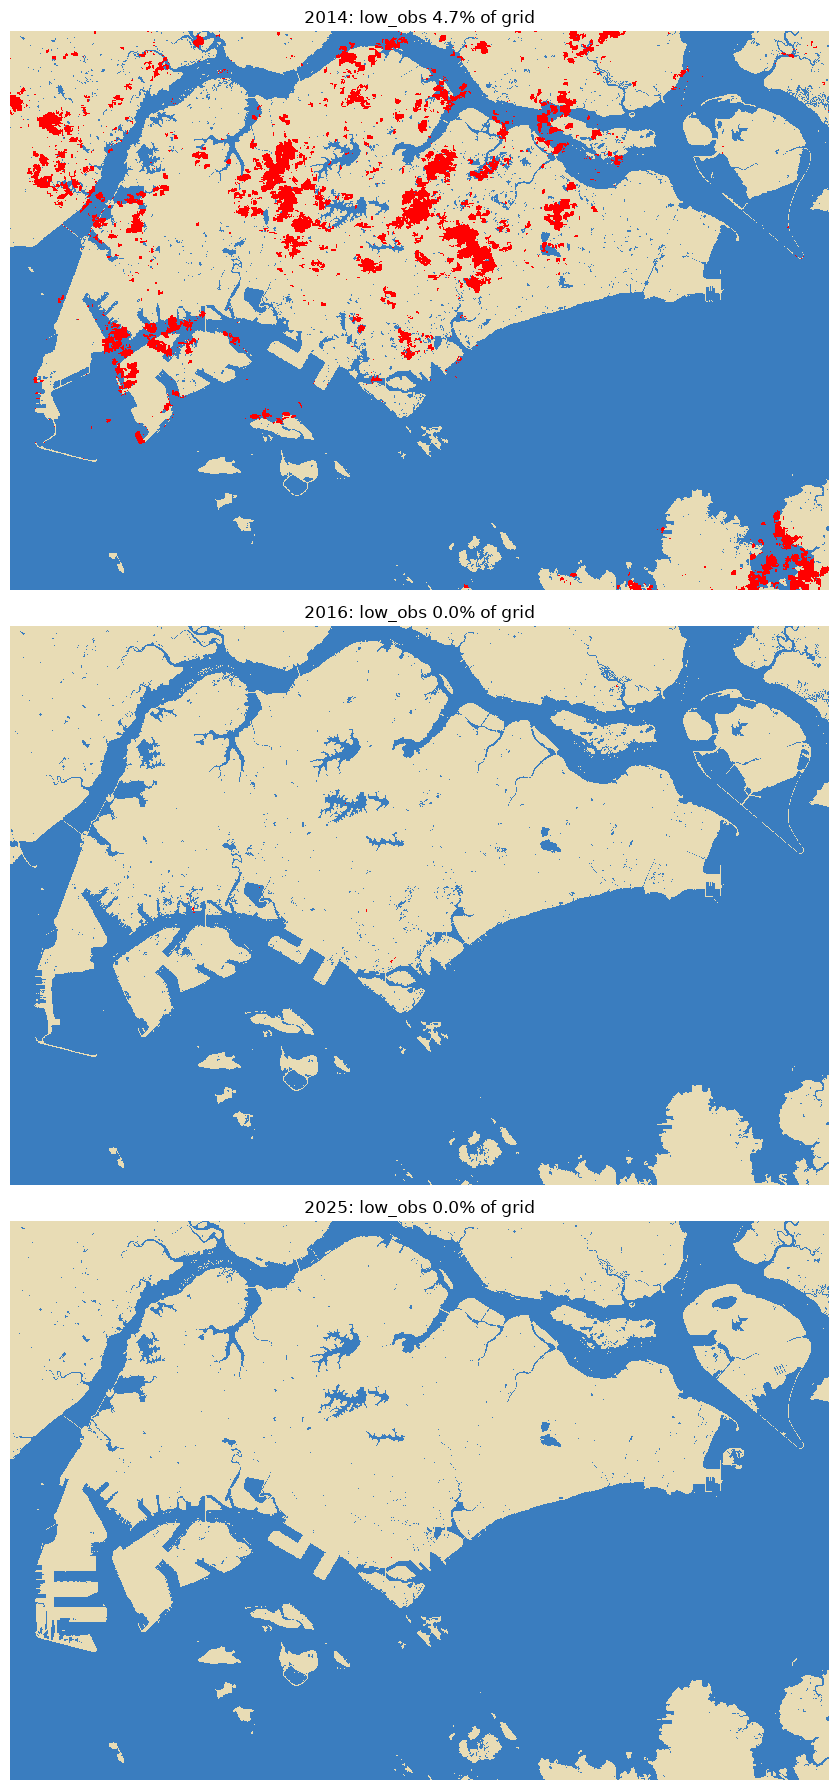

In [6]:
from matplotlib.colors import ListedColormap
years = [2014, 2016, 2025]
fig, axes = plt.subplots(len(years), 1, figsize=(12, 6 * len(years)))
for year, ax in zip(years, axes):
    with rasterio.open(classify.MASKS / f'mask_{year}.tif') as src:
        water, low = src.read(1), src.read(2)
    ax.imshow(np.ma.masked_equal(water, 255), cmap=ListedColormap(['#e8dcb5', '#3a7dbf']), interpolation='nearest')
    ax.imshow(np.ma.masked_equal(low, 0), cmap=ListedColormap(['red']), interpolation='nearest')
    ax.set_title(f'{year}: low_obs {low.mean() * 100:.1f}% of grid'); ax.set_axis_off()
fig.tight_layout()